<a href="https://colab.research.google.com/github/true-cpu/ThucHanhDeepLearning/blob/main/Buoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Nạp thư viện (Import Libraries)

Đầu tiên, chúng ta cần nạp các thư viện cần thiết cho việc xây dựng và huấn luyện mô hình Autoencoder, xử lý ảnh và hiển thị kết quả.

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [26]:
import os
import zipfile
import tensorflow as tf

ZIP_PATH = '/content/archive (1).zip'
EXTRACT_DIR = '/content/dataset_manual'

# 1. Giải nén và kiểm tra file zip
if os.path.exists(ZIP_PATH):
    try:
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        print(f"Đã giải nén thành công vào {EXTRACT_DIR}")
    except zipfile.BadZipFile:
        print(f"Lỗi: Tệp {ZIP_PATH} bị hỏng hoặc không phải là file zip. Vui lòng xóa tệp này và tải lên lại.")
else:
    print(f"Lỗi: Không tìm thấy file {ZIP_PATH}. Vui lòng tải file lên Colab.")

# 2. Tìm ảnh
all_image_paths = []
if os.path.exists(EXTRACT_DIR):
    for root, dirs, files in os.walk(EXTRACT_DIR):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_image_paths.append(os.path.join(root, file))

# 3. Cấu hình Dataset
IMG_WIDTH, IMG_HEIGHT, BATCH_SIZE = 128, 128, 32

def load_and_preprocess_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_WIDTH, IMG_HEIGHT])
    image = image / 255.0
    return image, image

if all_image_paths:
    print(f"Tìm thấy {len(all_image_paths)} ảnh.")
    NUM_SAMPLES = min(2000, len(all_image_paths))
    dataset = tf.data.Dataset.from_tensor_slices(all_image_paths[:NUM_SAMPLES])
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    print("Dataset đã sẵn sàng.")
else:
    print("Chưa có ảnh để xử lý. Vui lòng kiểm tra lại bước giải nén.")

Đã giải nén thành công vào /content/dataset_manual
Tìm thấy 8000 ảnh.
Dataset đã sẵn sàng.


In [27]:
def build_autoencoder(img_width, img_height, channels=3):
    # Encoder
    encoder_input = tf.keras.Input(shape=(img_width, img_height, channels))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Kích thước giảm một nửa
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Kích thước giảm một nửa nữa
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # Biểu diễn latent

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x) # Tăng kích thước
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x) # Tăng kích thước
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x) # Tăng kích thước
    decoded = layers.Conv2D(channels, (3, 3), activation='sigmoid', padding='same')(x) # Output ảnh với sigmoid

    # Autoencoder Model
    autoencoder = models.Model(encoder_input, decoded)

    # Encoder Model (dùng để trích xuất đặc trưng)
    encoder = models.Model(encoder_input, encoded)

    return autoencoder, encoder

# Xây dựng mô hình
autoencoder, encoder = build_autoencoder(IMG_WIDTH, IMG_HEIGHT, channels=3)
autoencoder.summary()

# Hiển thị cấu trúc của Encoder
print("\nEncoder Summary:")
encoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Huấn luyện mô hình (Train Model)

Chúng ta sẽ biên dịch mô hình Autoencoder với hàm mất mát (loss function) `binary_crossentropy` (thường dùng cho ảnh với pixel giá trị từ 0-1) hoặc `mse` (mean squared error) và trình tối ưu hóa (optimizer) `Adam`. Sau đó, chúng ta sẽ huấn luyện mô hình trên dataset đã chuẩn bị.

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - loss: 0.0308
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - loss: 0.0112
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - loss: 0.0089
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - loss: 0.0078
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - loss: 0.0079
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - loss: 0.0069
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - loss: 0.0066
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - loss: 0.0065
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - loss: 0.0062
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - loss: 0.0059


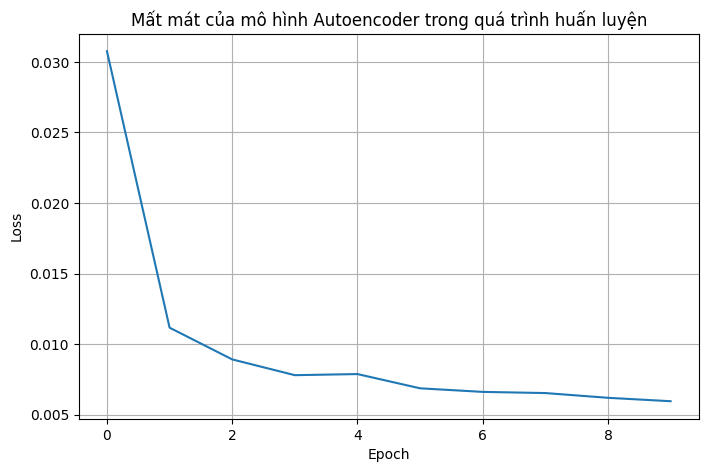

In [28]:
autoencoder.compile(optimizer='adam', loss='mse') # Sử dụng MSE cho việc tái tạo ảnh liên tục

# Huấn luyện mô hình
history = autoencoder.fit(
    dataset,
    epochs=10, # Có thể tăng số lượng epoch nếu cần
    shuffle=True
)

# Vẽ biểu đồ mất mát qua các epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.title('Mất mát của mô hình Autoencoder trong quá trình huấn luyện')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step


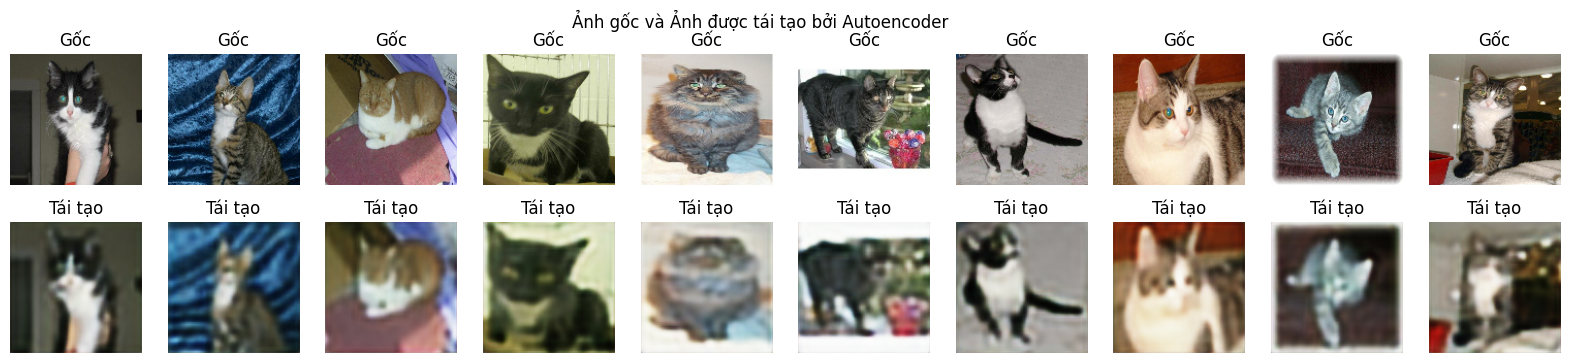


Autoencoder tái tạo ảnh thành công. Để nhận dạng chó/mèo, bạn có thể sử dụng đầu ra của Encoder làm đặc trưng cho một mô hình phân loại riêng biệt.


In [30]:
# Lấy một vài ảnh từ tập huấn luyện để kiểm tra
num_display_images = 10
original_images = []
for image, _ in dataset.take(1).unbatch().take(num_display_images):
    original_images.append(image.numpy())
original_images = np.array(original_images)

# Sử dụng Autoencoder để tái tạo ảnh
reconstructed_images = autoencoder.predict(original_images)

# Hiển thị ảnh gốc và ảnh được tái tạo
plt.figure(figsize=(20, 4))
for i in range(num_display_images):
    # Ảnh gốc
    ax = plt.subplot(2, num_display_images, i + 1)
    plt.imshow(original_images[i])
    plt.title("Gốc")
    plt.axis("off")

    # Ảnh được tái tạo
    ax = plt.subplot(2, num_display_images, i + 1 + num_display_images)
    plt.imshow(reconstructed_images[i])
    plt.title("Tái tạo")
    plt.axis("off")
plt.suptitle("Ảnh gốc và Ảnh được tái tạo bởi Autoencoder")
plt.show()

# Để làm rõ cách Autoencoder có thể được dùng cho nhận dạng:
# Bạn có thể trích xuất đặc trưng từ encoder và huấn luyện một bộ phân loại riêng biệt.
# features = encoder.predict(original_images)
# Sau đó huấn luyện một mô hình phân loại (ví dụ: SVM, Random Forest, hoặc một mạng neural nhỏ) trên 'features' này và nhãn tương ứng (cat/dog).
print("\nAutoencoder tái tạo ảnh thành công. Để nhận dạng chó/mèo, bạn có thể sử dụng đầu ra của Encoder làm đặc trưng cho một mô hình phân loại riêng biệt.")